# Упражнение 2.6

## Задание 1

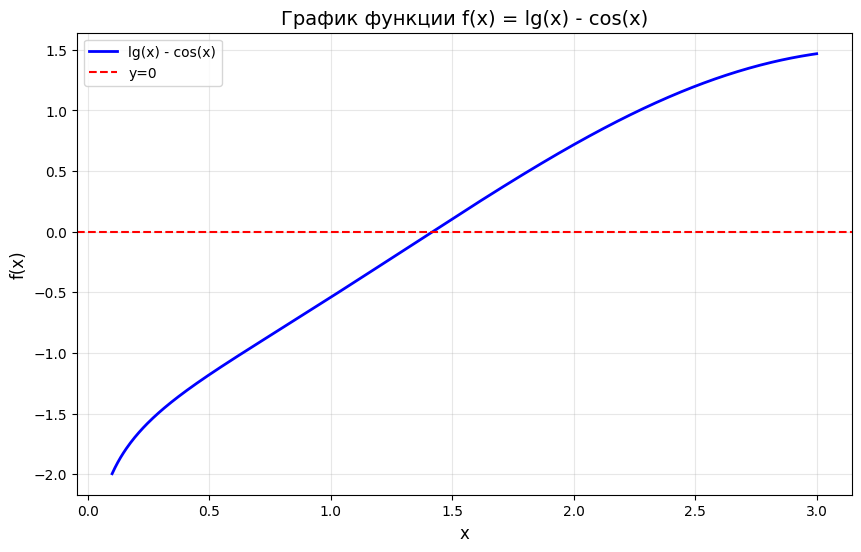

Приближенное значение корня: 1.4184


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Определение функции
def equation(x):
    return np.log10(x) - np.cos(x)

# Построение графика
x_vals = np.linspace(0.1, 3, 500)
y_vals = equation(x_vals)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='lg(x) - cos(x)')
plt.axhline(0, color='r', linestyle='--', label='y=0')
plt.grid(True, alpha=0.3)
plt.title('График функции f(x) = lg(x) - cos(x)', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend()
plt.show()

# Нахождение корня методом бисекции
left_bound, right_bound = 1.3, 1.5  # интервал из графика
tolerance = 1e-5
max_iterations = 30

for iteration in range(max_iterations):
    midpoint = (left_bound + right_bound) / 2
    
    if equation(left_bound) * equation(midpoint) < 0:
        right_bound = midpoint
    else:
        left_bound = midpoint
    
    if (right_bound - left_bound) < tolerance:
        break

print(f"Приближенное значение корня: {midpoint:.4f}")

## Задание 2

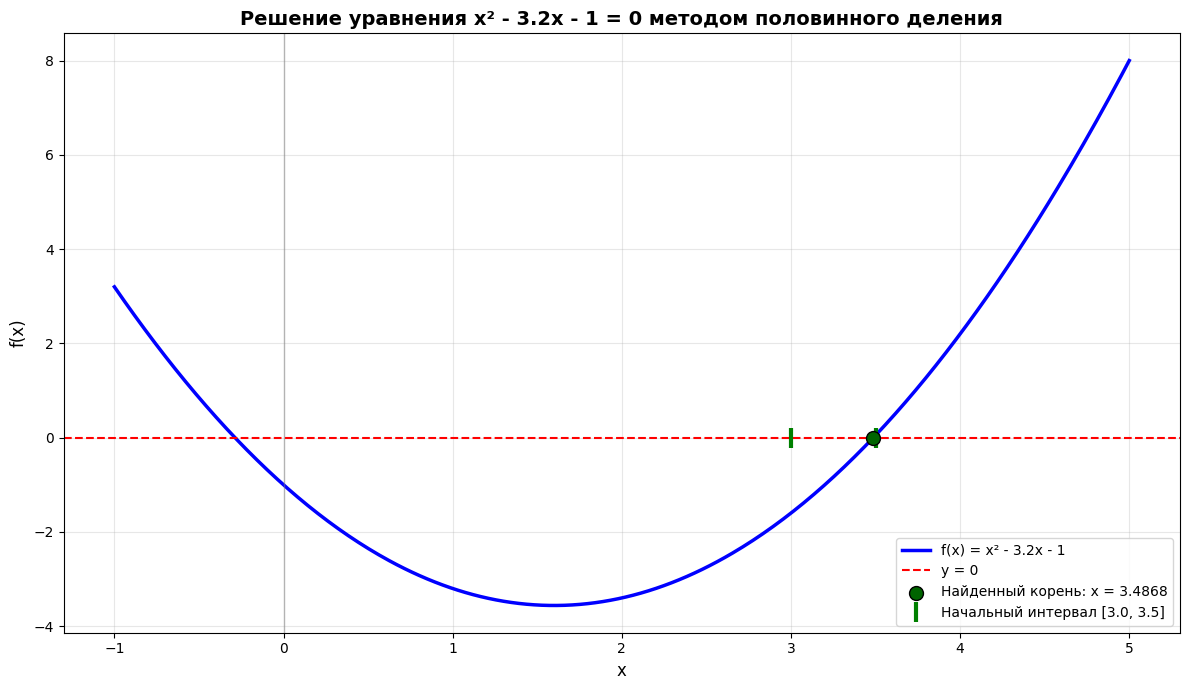

Корень уравнения: 3.4868


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Определение функции
def quadratic_function(x):
    return x**2 - 3.2*x - 1

# Параметры для метода половинного деления
left_endpoint, right_endpoint = 3.0, 3.5
precision = 1e-5
max_iterations = 30

# Нахождение корня методом бисекции
for iteration in range(max_iterations):
    midpoint = (left_endpoint + right_endpoint) / 2
    
    if quadratic_function(left_endpoint) * quadratic_function(midpoint) < 0:
        right_endpoint = midpoint
    else:
        left_endpoint = midpoint
    
    if (right_endpoint - left_endpoint) < precision:
        break

# Построение графика
x_values = np.linspace(-1, 5, 400)
y_values = quadratic_function(x_values)

plt.figure(figsize=(12, 7))
plt.plot(x_values, y_values, 'b-', linewidth=2.5, label='f(x) = x² - 3.2x - 1')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='y = 0')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)

# Отметка найденного корня
plt.scatter(midpoint, 0, color='darkgreen', s=100, zorder=5, 
           label=f'Найденный корень: x = {midpoint:.4f}', edgecolors='black')

# Отметка исходного интервала
plt.plot([3.0, 3.5], [0, 0], 'g|', markersize=15, markeredgewidth=3, 
         label='Начальный интервал [3.0, 3.5]')

plt.grid(True, alpha=0.3, linestyle='-')
plt.title('Решение уравнения x² - 3.2x - 1 = 0 методом половинного деления', 
          fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Корень уравнения: {midpoint:.4f}")

## Задание 3

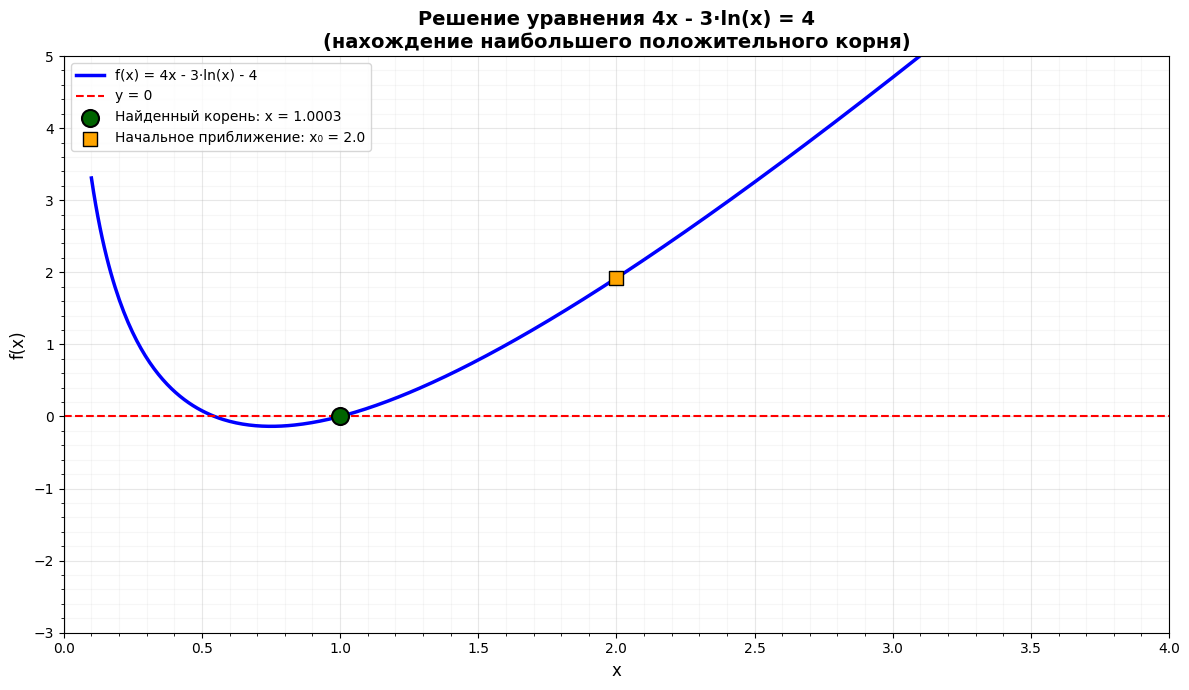

Наибольший положительный корень: 1.0003
Проверка подстановкой:
4 · 1.0003 - 3 · ln(1.0003) = 4.000261
Ожидаемое значение: 4
Абсолютная погрешность: 0.000261


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Определение исходной функции
def original_function(x):
    """Исходная функция: 4x - 3ln(x) - 4"""
    if x <= 0:
        return np.nan
    return 4*x - 3*np.log(x) - 4

# Итерационная функция для метода простых итераций
def iteration_function(x):
    """φ(x) = (4 + 3ln(x)) / 4"""
    return (4 + 3*np.log(x)) / 4

# Параметры метода итераций
initial_guess = 2.0  # начальное приближение
tolerance = 1e-4      # точность
max_iterations = 30   # максимальное число итераций

# 1. Нахождение корня методом простых итераций
current_x = initial_guess
for iteration in range(max_iterations):
    next_x = iteration_function(current_x)
    
    if abs(next_x - current_x) < tolerance:
        break
        
    current_x = next_x

found_root = next_x

# 2. Построение графика
x_domain = np.linspace(0.1, 4, 500)
y_values = np.array([original_function(val) for val in x_domain])

plt.figure(figsize=(12, 7))

# Основной график функции
plt.plot(x_domain, y_values, 'b-', linewidth=2.5, 
         label='f(x) = 4x - 3·ln(x) - 4')

# Опорные линии
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='y = 0')
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)

# Отметка найденного корня
plt.scatter(found_root, 0, color='darkgreen', s=150, zorder=5,
           label=f'Найденный корень: x = {found_root:.4f}', 
           edgecolors='black', linewidth=1.5)

# Отметка начального приближения
plt.scatter(initial_guess, original_function(initial_guess), 
           color='orange', s=100, zorder=4, marker='s',
           label=f'Начальное приближение: x₀ = {initial_guess}', 
           edgecolors='black')

# Настройки графика
plt.grid(True, alpha=0.3, linestyle='-')
plt.title('Решение уравнения 4x - 3·ln(x) = 4\n(нахождение наибольшего положительного корня)', 
          fontsize=14, fontweight='bold')
plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.xlim(0, 4)
plt.ylim(-3, 5)

# Добавление сетки для лучшей читаемости
plt.minorticks_on()
plt.grid(True, which='minor', alpha=0.1)

plt.tight_layout()
plt.show()

# Вывод результатов с проверкой
print(f"Наибольший положительный корень: {found_root:.4f}")
print(f"Проверка подстановкой:")
print(f"4 · {found_root:.4f} - 3 · ln({found_root:.4f}) = {4*found_root - 3*np.log(found_root):.6f}")
print(f"Ожидаемое значение: 4")
print(f"Абсолютная погрешность: {abs(4 - (4*found_root - 3*np.log(found_root))):.6f}")